In [1]:
!pip install nltk --quiet

In [2]:
import re 
import math 
from collections import Counter 
from typing import List, Tuple, Dict 
import matplotlib.pyplot as plt 
import random 
random.seed(13)

In [3]:
def simple_tokenize(text: str) -> List[str]:
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.split()

In [4]:
def add_sentence_markers(tokens: List[str], n:int) -> List[str]:
    k = n - 1
    return (['<s>'] * k + tokens + ['</s>']) 
def ngrams(seq: List[str], n:int) -> List[Tuple[str, ...]]:
    return [ tuple(seq[i:i+n]) for i in range(len(seq) - n + 1)]
def train_test_split(tokens: List[str], test_ratio = 0.2):
    split_index = int(len(tokens) * (1 - test_ratio))
    return tokens[:split_index], tokens[split_index:]
print("setup complete")


setup complete


In [5]:
toy_text = """
I love NLP and I love building language models.
Language models help phones suggest the next word.
I am going to the store to buy some apples.
I am going to the gym after work.
We love natural language processing and we study NLP.
Unicorns are rare but language is creative and flexible.
"""
#tokenize to lower words
tokens = simple_tokenize(toy_text)
print(tokens[:30])
print("Total tokens:", len(tokens))

['i', 'love', 'nlp', 'and', 'i', 'love', 'building', 'language', 'models', 'language', 'models', 'help', 'phones', 'suggest', 'the', 'next', 'word', 'i', 'am', 'going', 'to', 'the', 'store', 'to', 'buy', 'some', 'apples', 'i', 'am', 'going']
Total tokens: 53


In [6]:
def build_vocab(tokens: List[str], min_frq = 1) -> Dict[str, int]:
    freqs = Counter(tokens)
    vocab = {"<unk>": 0, "<s>":1, "</s>":2}
    for w,c in freqs.items():
        if c >= min_frq and w not in vocab:
            vocab[w] = len(vocab) 
    return vocab 
def map_to_vocab(tokens: List[str], vocab: Dict[str, int]) -> List[str]:
    return [w if w in vocab else "<unk>" for w in tokens]

def build_ngram_counts(tokens: List[str], n:int) -> Counter:
    return Counter(ngrams(tokens, n))
# Build vocab and split data
vocab = build_vocab(tokens, min_frq = 1) 
train_toks = tokens 
test_toks = []
#Prepare sequences with sentence markers 
N = 3 
train_seq = add_sentence_markers(map_to_vocab(train_toks, vocab), N) 
test_seq = add_sentence_markers(map_to_vocab(test_toks, vocab), N)
#count unigram/ bigram/ trigram
uni_counts = build_ngram_counts(train_seq, 1)
bi_counts = build_ngram_counts(train_seq, 2)
tri_counts = build_ngram_counts(train_seq, 3)

V = len(vocab)
print("Vocabulary size:", V)
print("train_toksoks", train_seq)
print("Top unigrams:", uni_counts.most_common(8)) 
print("Top bigrams:", bi_counts.most_common(8)) 
print("Top trigrams:", tri_counts.most_common(8)) 

Vocabulary size: 37
train_toksoks ['<s>', '<s>', 'i', 'love', 'nlp', 'and', 'i', 'love', 'building', 'language', 'models', 'language', 'models', 'help', 'phones', 'suggest', 'the', 'next', 'word', 'i', 'am', 'going', 'to', 'the', 'store', 'to', 'buy', 'some', 'apples', 'i', 'am', 'going', 'to', 'the', 'gym', 'after', 'work', 'we', 'love', 'natural', 'language', 'processing', 'and', 'we', 'study', 'nlp', 'unicorns', 'are', 'rare', 'but', 'language', 'is', 'creative', 'and', 'flexible', '</s>']
Top unigrams: [(('i',), 4), (('language',), 4), (('love',), 3), (('and',), 3), (('the',), 3), (('to',), 3), (('<s>',), 2), (('nlp',), 2)]
Top bigrams: [(('i', 'love'), 2), (('language', 'models'), 2), (('i', 'am'), 2), (('am', 'going'), 2), (('going', 'to'), 2), (('to', 'the'), 2), (('<s>', '<s>'), 1), (('<s>', 'i'), 1)]
Top trigrams: [(('i', 'am', 'going'), 2), (('am', 'going', 'to'), 2), (('going', 'to', 'the'), 2), (('<s>', '<s>', 'i'), 1), (('<s>', 'i', 'love'), 1), (('i', 'love', 'nlp'), 1), 

In [7]:
def bigram_mle_prob(w_prev: str, w:str) -> float:
    "P(w  | w_prev) = count(w_prev, w) / count(w_prev) "
    "it returns 0 if denominator is 0 (unseen history)" 
    c_bigram = bi_counts.get((w_prev, w), 0)
    c_prev = uni_counts.get((w_prev,), 0)
    return (c_bigram/ c_prev) if c_prev > 0 else 0.0 
def trigram_mle_prob(w1: str, w2: str, w3: str):
    c_trigram = tri_counts.get((w1, w2, w3), 0)
    c_hist = bi_counts.get((w1, w2), 0)
    return (c_trigram/ c_hist) if c_hist > 0 else 0.0 
def sentence_logprob_mle(sent_tokens: List[str], n = 3) -> float:
    seq = add_sentence_markers(map_to_vocab(sent_tokens, vocab, ), n) 
    logp = 0.0 
    for (w1, w2, w3) in ngrams(seq, 3):
        p = trigram_mle_prob(w1, w2, w3)
        if p == 0.0:
            return float("-inf")
        logp += math.log(p)
    return logp
example = simple_tokenize("I saw a unicorn today") 
print("Trigram MLE long-prob:", sentence_logprob_mle(example, n = 3))


Trigram MLE long-prob: -inf


# Add 1 or k smoothing

In [8]:
def bigram_addk_prob(w_prev: str, w: str, k : float) -> float:
    number = bi_counts.get((w_prev, w), 0) + k 
    denom = uni_counts.get((w_prev,), 0) + k * V
    return (number/ denom) if denom > 0 else (1.0/ V)
def trigram_addk_prob(w1:str, w2:str, w3:str, k: float):
    number = tri_counts.get((w1, w2, w3), 0) + k 
    denom = bi_counts.get((w1,w2), 0) + k * V 
    return (number / denom) if denom > 0 else (1.0/ V)
def sentence_logprob_addk(sent_tokens: List[str], n = 3, k = 1.0) -> float:
    seq = add_sentence_markers(map_to_vocab(sent_tokens, vocab), n)
    logp = 0.0 
    for (w1, w2, w3) in ngrams(seq,3):
        p = trigram_addk_prob(w1, w2, w3, k)
        logp += math.log(max(p, 1e-12))
    return logp 
for k in [0.0, 0.1, 0.5, 1.0]:
    print(f"Add-k (k = {k} trigram log-prob)", sentence_logprob_addk(example,n = 3,  k=k))





Add-k (k = 0.0 trigram log-prob) -42.07469276650545
Add-k (k = 0.1 trigram log-prob) -19.746071581198645
Add-k (k = 0.5 trigram log-prob) -20.672182654168083
Add-k (k = 1.0 trigram log-prob) -21.025696789469723


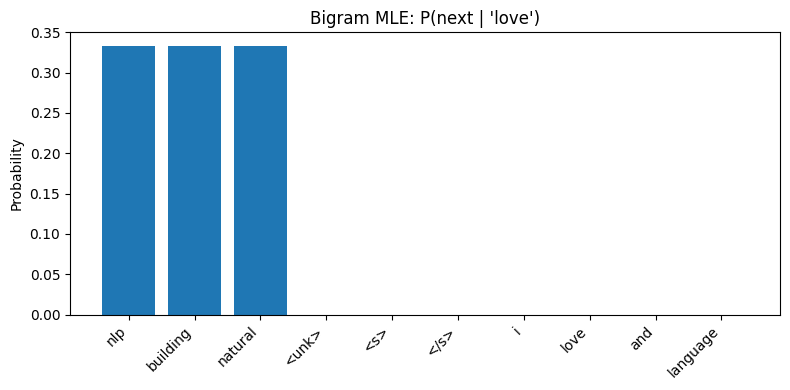

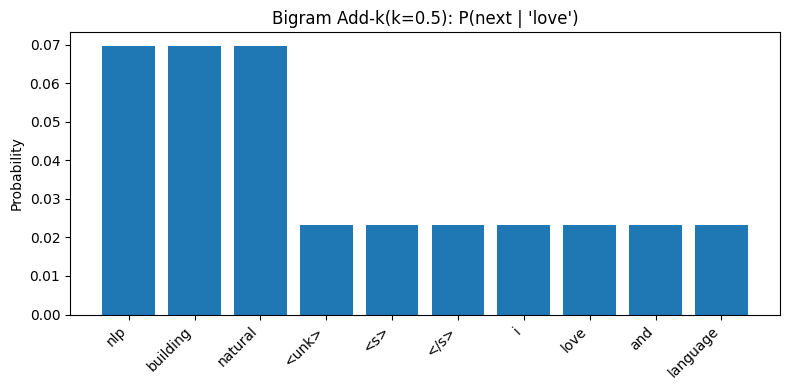

In [9]:
def top_next_words_bigram(history : str, topk = 10, mode = "mle", k = 0.5):
    ws = list(vocab.keys())
    scores = []
    for w in ws:
        if mode == "mle":
            p = bigram_mle_prob(history, w) 
        elif mode == "addk":
            p = bigram_addk_prob(history, w, k)
        else:
            raise ValueError("mode must be either 'mle' or 'addk'")
        scores.append((w,p))
    scores.sort(key = lambda x: x[1], reverse = True)
    return scores[:topk]
def plot_bar(labels, values, title):
    plt.figure(figsize = (8,4))
    plt.bar(labels, values)
    plt.title(title)
    plt.xticks(rotation = 45, ha = 'right')
    plt.ylabel("Probability")
    plt.tight_layout()
    plt.show()
history = "love" if "love" in vocab else "<unk>"

top_mle = top_next_words_bigram(history, mode="mle")
top_addk = top_next_words_bigram(history, mode="addk", k=0.5)

labels_mle = [w for w, _ in top_mle]
vals_mle = [p for _, p in top_mle]
plot_bar(labels_mle, vals_mle, f"Bigram MLE: P(next | '{history}')")

labels_addk = [w for w, _ in top_addk]
vals_addk = [p for _, p in top_addk]
plot_bar(labels_addk, vals_addk, f"Bigram Add-k(k=0.5): P(next | '{history}')")


# Backoff Smoothing

In [ ]:
total_tokens = sum(uni_counts.values())
print(total_tokens)   

56


In [11]:
def unigram_prob(w: str) -> float:
    return uni_counts((w,), 0) / max(1, total_tokens)


In [13]:
def backoff_prob(w1:str, w2:str, w3:str, k_bigram = 0.1, alpha = 0.4) -> float:
    p_tri = trigram_addk_prob(w1,w2,w3, k = 0.1)
    if p_tri > 0:
        return p_tri 
    p_bi = bigram_addk_prob(w2, w3, k = k_bigram)
    if p_bi > 0:
        return alpha * p_bi 
    return (alpha ** 2) * unigram_prob(w3)
def sentence_logprob_backoff(sent_tokens: List[str]) -> float:
    seq = add_sentence_markers(map_to_vocab(sent_tokens, vocab), 3)
    logp = 0.0 
    for (w1, w2, w3) in ngrams(seq, 3):
        p = max(backoff_prob(w1, w2, w3), 1e-12)
        logp += math.log(p)
    return logp 
print("Backoff trigram log-prob:", sentence_logprob_backoff(example))


Backoff trigram log-prob: -19.746071581198645


# Interpolation

In [ ]:
def trigram_interp_prob(w1, w2, w3, lambdas = (0.7, 0.4, 0.2), k_bigram = 0.1):
    l3, l2, l1 = lambdas 
    p3 = trigram_mle_prob(w1, w2, w3)
    p2 = bigram_addk_prob(w2, w3, k = k_bigram)
    p1 = unigram_prob(w3)
    return l3 * p3  + l2 * p2 + l1 * p1 
def learn_lambdas_heldout(train_tokens: List[str], heldout_tokens: List[str], grid = (0.0, 0.25, 0.5, 0.75, 1.0)):
    heldout_seq = add_sentence_markers(map_to_vocab(heldout_tokens, vocab), 3)
    def heldout_loglik(lmb):
        l3, l2, l1 = lmb 
        if abs((l1 + l2 + l3) - 1.0) > 1e-9:
            return float("-inf")
        s = 0.0 
        for (w1, w2, w3) in ngrams(heldout_seq, 3):
            p = max(trigram_interp_prob(w1, w2, w3, lambdas = lmb), 1e-12)
            s += math.log(p)
        return s
    best = (float("-inf"), 0.6, 0.3, 0.1)
    for l3 in grid:
        for l2 in grid:
            l1 = 1.0 - l3 - l2 
            if l1 < 0 and l1 > 1:
                continue 
            score = heldout_loglik((l3, l2, l1))
            if score > best[0]:
                best = (score, l3, l2, l1)
    return best
split = int(len(train_toks) * 0.8)
heldout = train_toks[split:]
